In [1]:
import torch
from torch import nn
from torch import optim as optim
from torch.nn import functional as F

import sys
sys.path.insert(1, 'helpers')
from dlc_practical_prologue import *
from helpers import *

%load_ext autoreload
%autoreload 2

# Auxiliary Nets

In [106]:
# Deterministic version: usually ~0.88 for train and val after 25 epochs

# Other Modes: Step, Gradual, Final, Constant - See "train_aux_model" to see what these modes do

class AuxNet1(nn.Module):
    def __init__(self,Type="Deterministic"):
        super(AuxNet1,self).__init__()
        
        # Type
        self.type = Type
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(1,16,kernel_size=4,padding=1,stride=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3,padding=0,stride=1)
        self.conv2 = nn.Conv2d(16,64,kernel_size=2,padding=0,stride=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2,padding=0,stride=2)
        self.conv3 = nn.Conv2d(64,128,kernel_size=1,padding=0,stride=1)
        self.conv4 = nn.Conv2d(128,64,kernel_size=2,padding=0,stride=1)
        self.conv5 = nn.Conv2d(64,16,kernel_size=3,padding=0,stride=1)
        self.fct = nn.Linear(64,10)
        
        # Recombination Layers
        self.fc1 = nn.Linear(20,32)
        self.fc2 = nn.Linear(32,64)
        self.fc3 = nn.Linear(64,2)
    def Convolve(self,x):
        x = self.conv1(x)
        x = F.relu(x) # 16x13x13
        x = self.maxpool1(x)
        x = F.relu(x) # 16x11x11
        x = self.conv2(x)
        x = F.relu(x) # 64x10x10
        x = self.maxpool2(x)
        x = F.relu(x) # 64x5x5
        x = self.conv3(x)
        x = F.relu(x) # 128x5x5
        x = self.conv4(x)
        x = F.relu(x) # 64x4x4
        x = self.conv5(x)
        x = F.relu(x) # 16x2x2
        x = self.fct(x.view(-1,64))
        return x
    
    def DeterministicRecombine(self,x1,x2):
        nb_samples = x1.size(0)
        x = torch.zeros(nb_samples,2)
        for i in range(nb_samples):
            _,j = x1[i].max(0)
            _,k = x2[i].max(0)
            
            if j.item()<k.item():
                x[i,1]=1
            else:
                x[i,0]=1
        return x
    
    def NetworkRecombine(self,x1,x2):
        x = torch.cat((x1,x2),1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
        
    def forward(self,x): # 1x14x14
        
        x1 = self.Convolve(x[:,0:1])
        x2 = self.Convolve(x[:,1:2])
        if self.type == "Deterministic":
            x = self.DeterministicRecombine(x1,x2)
        elif self.type == "Final":
            x = self.NetworkRecombine(x1,x2)
        else:
            x = self.NetworkRecombine(x1.detach(),x2.detach())
        
        return x, x1, x2

# Training Function

In [107]:
def train_aux_model(model, rounds, nb_epochs=100, batch_size=100, validation=True, verbose=True):
                
    nb_epochs_shown = 10
    
    criterion = nn.CrossEntropyLoss()
    aux_criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    
    # tensors for averaging over the rounds
    times = torch.zeros(rounds)
    train_acc = torch.zeros(rounds)
    test_acc = torch.zeros(rounds)
    train_loss = torch.zeros(rounds, nb_epochs + 1)
    validation_loss = torch.zeros(rounds, nb_epochs + 1)
    
    for r in range(rounds):
        
        # new data
        train_input, train_target, train_classes, val_input, val_target, val_classes = generate_pair_sets(nb=1000)
        
        aux_target1 = train_classes[:,0]
        aux_target2 = train_classes[:,1]
        aux_val_target1 = val_classes[:,0]
        aux_val_target2 = val_classes[:,1]
        
        # reset weights
        model.apply(weight_reset) 
        
        t0 = time.time()

        for e in range(nb_epochs):
            
            # store the train and validation loss for each epoch and round 
            if validation:
                model.train(False) # deactivate dropout
                train_loss[r,e] = criterion(model(train_input)[0], train_target)
                validation_loss[r,e] = criterion(model(val_input)[0], val_target)
                model.train(True) # activate dropout
            
            # updating the model
            for inputs, targets, aux_targets1, aux_targets2 in zip(train_input.split(batch_size), 
                                               train_target.split(batch_size), 
                                               aux_target1.split(batch_size),
                                               aux_target2.split(batch_size)):
                
                output1, aux_output1, aux_output2 = model(inputs)
                loss = criterion(output1, targets)
                loss_aux1 = aux_criterion(aux_output1,aux_targets1)
                loss_aux2 = aux_criterion(aux_output2,aux_targets2)
                
                if model.type == "Deterministic":
                    c_loss = 0
                    c_aux = 1
                elif model.type == "Step":
                    if e<nb_epochs/4:
                        c_loss = 0
                        c_aux = 1
                    else:
                        c_loss = 1
                        c_aux = 0
                elif model.type == "Gradual":
                    c_loss = torch.sigmoid(-1e10*torch.tensor([e-float(nb_epochs)/5.])).item()
                    c_aux = torch.sigmoid(1e10*torch.tensor([e-float(nb_epochs)/5.])).item()
                elif model.type == "Constant":
                    c_loss = 1
                    c_aux = 1
                elif model.type == "Final":
                    c_loss = 1
                    c_aux = 0
                else:
                    c_loss = 1
                    c_aux = 1
                loss =  c_loss * loss + c_aux*(loss_aux1 + 0*loss_aux2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # print the loss for a given number of epochs - used for direct feedback
            if verbose:
                if((e + 1) % int(nb_epochs / nb_epochs_shown) == 0):
                    print("Epoch {} | Train loss : {}".format(e+1, loss))
                    
        # final loss            
        if validation:
            model.train(False) # deactivate dropout
            train_loss[r,nb_epochs] = criterion(model(train_input)[0], train_target)
            validation_loss[r,nb_epochs] = criterion(model(val_input)[0], val_target)
            model.train(True) # activate dropout

        t1 = time.time()
        
        times[r] = t1-t0
        train_acc[r] = accuracy(model, train_input, train_target)
        test_acc[r] = accuracy(model, val_input, val_target)
        
        print('Round {} done.'.format(r+1))
        
    print('--------------')
    
    total_trained_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("Model : {} \n".format(model.__class__.__name__ ) + \
          "Number of trained parameters : {} \n".format(total_trained_params) + \
          "Size of mini-batches : {}\n".format(batch_size) + \
          "Averaged on {} rounds \n".format(rounds) + \
          "    Time for {} epochs : {:.2f}s\n".format(nb_epochs, times.mean().item()) + \
          "    Train accuracy : {:.3f} \n".format(train_acc.mean().item()) + \
          "    Test accuracy : {:.3f}".format(test_acc.mean().item()))
    
    return train_loss.detach().mean(dim=0),train_loss.detach().var(dim=0), validation_loss.detach().mean(dim=0),validation_loss.detach().var(dim=0),model

# Training

In [111]:
rounds = 1
model = AuxNet1("Step")
train_loss,train_var,val_loss,val_var,model = train_aux_model(model, rounds,nb_epochs=100, validation=True)

Epoch 10 | Train loss : 0.20686717331409454
Epoch 20 | Train loss : 0.01786264032125473
Epoch 30 | Train loss : 0.2611473500728607
Epoch 40 | Train loss : 0.1336258202791214
Epoch 50 | Train loss : 0.09532888233661652
Epoch 60 | Train loss : 0.11980865150690079
Epoch 70 | Train loss : 0.06995734572410583
Epoch 80 | Train loss : 0.05897205322980881
Epoch 90 | Train loss : 0.050170306116342545
Epoch 100 | Train loss : 0.04307414963841438
Round 1 done.
--------------
Model : AuxNet1 
Number of trained parameters : 58380 
Size of mini-batches : 100
Averaged on 1 rounds 
    Time for 100 epochs : 162.09s
    Train accuracy : 0.980 
    Test accuracy : 0.859


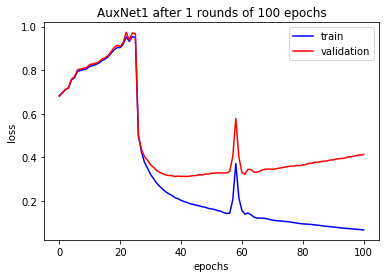

In [112]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6,4))


plt.plot(train_loss,'b',label='train')
plt.plot(val_loss,'r', label='validation')

# 95% confidence intervalles if 5 rounds
if torch.isnan(train_var[0])==False and rounds==5:
    s5 = 2.015
    i=0
    for trainm,trainv,valm,valv in zip(train_loss,train_var,val_loss,val_var): 
        x = np.array([i,i])
        y1 = np.array([trainm-s5*trainv,trainm+s5*trainv])
        y2 = np.array([valm-s5*valv,valm+s5*valv])
        plt.plot(x,y1,'b')
        plt.plot(x,y2,'r')
        i+=1

nb_epochs = train_loss.shape[0]

ax.legend()
plt.title("{}".format(model.__class__.__name__ )+" after {} rounds".format(rounds)+" of {} epochs".format(nb_epochs-1))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()